## 📊 Business Impact & ROI Analysis: From Data to Profit

### 🎯 Objective
The final stage of this project answers a critical business question: **"What is the actual financial gain of implementing these personalized promotions?"** Instead of looking only at sales volume, this analysis focuses on **Net Profitability**, ensuring that the shop owner doesn't lose money by offering discounts that exceed product margins.

---

### 🧠 Methodology & Key Sections

#### 1. Data Enrichment & Integration
We merge the **Market Basket Analysis (MBA)** results with our historical product database. This brings in essential financial metrics:
* **Unit Price**: To value the transactions.
* **Department Category**: To apply industry-standard profit margins (e.g., 15% for Dairy, 40% for Alcohol).

#### 2. Realistic Sales Uplift Modeling
We apply a marketing-driven uplift factor based on the discount value:
* **10% Discount** $\rightarrow$ +15% probability of purchase.
* **20% Discount** $\rightarrow$ +35% probability of purchase.

#### 3. The "Director's" Profit Formula
The model calculates the **Net Unit Margin** by subtracting the cost of the discount from the estimated gross margin.
We also apply a **Cannibalization Factor (0.7)**, acknowledging that some customers would have bought the product even without the promo.

$$Total\ Profit = (Unit\ Price \times (Margin\% - Discount\%)) \times (Baseline\ Conversion + (Incremental\ Sales \times 0.7))$$

#### 4. Automated Decision Making (`verdict`)
The algorithm automatically tags each offer:
* **✅ GO**: The promotion is profitable and generates net margin.
* **❌ NO GO**: The promotion leads to a "Loss Leader" situation where the discount is higher than the margin.

---

### 📈 Key Performance Indicators (KPIs)
* **💰 Validated Net Profit**: Total cash gain from profitable "GO" offers.
* **🛡️ Saved Margin (Avoided Losses)**: The financial disaster prevented by blocking unprofitable "NO GO" promotions.
* **📍 Cluster Performance**: Identifies which customer segment is the most responsive and profitable.

---

### 📂 Deliverables
* **`RAPPORT_FINAL_PROFIT_NET.csv`**: A line-by-line decision tool for the store manager to approve or reject specific offers.
* **Strategic Chart**: A visual breakdown of profits vs. avoided losses across all customer clusters.

🏢 PERFORMANCE REPORT MANAGEMENT
💰 APPROVED NET PROFIT : 5378.44 €
🛡️ AVOIDED LOSSES : 173.62 €
✅ CSV file successfully exported : ../data/outputs/FINAL REPORT_NET PROFIT.csv


C:\Users\natha\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\natha\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


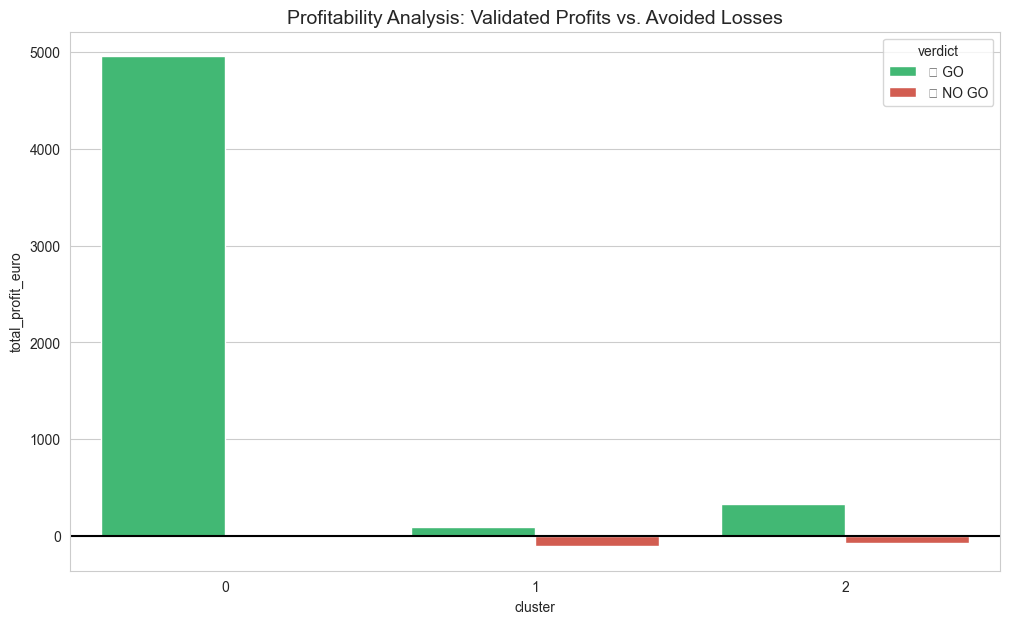

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOADING AND JOINING
df_campaign = pd.read_csv("../data/outputs/final_campaign_offers.csv")
df_enriched = pd.read_csv("../data/processed/df_enriched_final.csv")

ref_data = df_enriched[['product_name', 'unit_price', 'department']].drop_duplicates('product_name')
df_final = df_campaign.merge(ref_data, left_on='product_name_right', right_on='product_name', how='left')
df_final = df_final.drop(columns=['product_name_y']).rename(columns={'product_name_x': 'product_name'})
df_final['unit_price'] = df_final['unit_price'].fillna(df_final['unit_price'].mean())

# 2. BUSINESS CONFIGURATION
margins_config = {
    'alcohol': 0.40, 'personal care': 0.35, 'household': 0.30, 'produce': 0.35,
    'meat seafood': 0.25, 'pantry': 0.25, 'snacks': 0.25, 'beverages': 0.25,
    'dairy eggs': 0.15, 'babies': 0.15, 'frozen': 0.25
}

# 3. CALCULATING THE OVERALL ROI
def compute_complete_roi(df):
    # Probabilities
    df['discount_rate'] = df['discount_value'].str.replace('%', '').astype(float) / 100
    uplift_map = {0.10: 1.15, 0.20: 1.35}
    df['prob_promo'] = (df['confidence'] * df['discount_rate'].map(uplift_map)).clip(upper=1.0)
    df['inc_sales'] = df['prob_promo'] - df['confidence']
    df['incremental_revenue'] = df['inc_sales'] * df['unit_price']

    # Margin
    df['margin_rate'] = df['department'].map(margins_config).fillna(0.20)
    df['unit_margin_net'] = df['unit_price'] * (df['margin_rate'] - df['discount_rate'])

    # Profit with Cannibalisation (0.7)
    df['total_profit_euro'] = df['unit_margin_net'] * (df['confidence'] + (df['inc_sales'] * 0.7))

    # HARMONISED VERDICT
    df['verdict'] = df['unit_margin_net'].apply(lambda x: "✅ GO" if x > 0 else "❌ NO GO")
    return df

df_final = compute_complete_roi(df_final)

# 4. VALUE ADDED ANALYSIS
pertes_evitees = df_final[df_final['unit_margin_net'] < 0]['total_profit_euro'].sum()
df_go = df_final[df_final['verdict'] == "✅ GO"]

print("="*50)
print("🏢 PERFORMANCE REPORT MANAGEMENT")
print(f"💰 APPROVED NET PROFIT : {df_go['total_profit_euro'].sum():.2f} €")
print(f"🛡️ AVOIDED LOSSES : {abs(pertes_evitees):.2f} €")
print("="*50)

# Exporting the final report for the Director
df_final.to_csv("../data/outputs/FINAL_REPORT_NET_PROFIT.csv", index=False, encoding='utf-8-sig')

print("✅ CSV file successfully exported : ../data/outputs/FINAL_REPORT_NET_PROFIT.csv")

# 5. FINAL GRAPH (ROBUST)
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

summary_plot = df_final.groupby(['cluster', 'verdict'])['total_profit_euro'].sum().reset_index()

ax = sns.barplot(
    data=summary_plot,
    x='cluster',
    y='total_profit_euro',
    hue='verdict',
    palette={'✅ GO': '#2ecc71', '❌ NO GO': '#e74c3c'}
)

plt.axhline(0, color='black', linewidth=1.5)
plt.title('Profitability Analysis: Validated Profits vs. Avoided Losses', fontsize=14)
plt.show()